<div align="center">

## Analysis of Barren Plateaus in Machine Learning Training

### Анализ «бесплодных плато» при проведении анализа обучения моделей машинного обучения (Barren Plateaus)
</div>

### Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler

import pennylane as qml
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

### Additional functions

In [2]:
def plot_decision_boundary(model, X, y, title, is_torch=False):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_torch:
        with torch.no_grad():
            Z = model(torch.tensor(grid, dtype=torch.float32)).numpy()
    else:
        Z = model.predict_proba(grid)[:, 1]

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, levels=30, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=25, edgecolor="k")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

In [3]:
def training_plot(losses: list, title='VQC Training Progress'):
    plt.figure(figsize=(7,5))
    plt.plot(range(1, len(losses) + 1), losses, 'b-', linewidth=2, label='Training Loss')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)

### Machine Learning and Quantum Hybrid Models

#### Pytorch MLP

In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[16,16], output_dim=1):
        super(MLP, self).__init__()
        layers = []
        last_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(last_dim, h_dim))
            layers.append(nn.ReLU())
            last_dim = h_dim
        layers.append(nn.Linear(last_dim, output_dim))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=100, lr=0.01):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses

    def predict(self, X_test):
        self.model.eval()
        X_t = torch.tensor(X_test, dtype=torch.float32)
        with torch.no_grad():
            preds = self.model(X_t).squeeze()
        return (preds > 0.5).int().numpy()

    def predict_proba(self, X_test):
        self.model.eval()
        X_t = torch.tensor(X_test, dtype=torch.float32)
        with torch.no_grad():
            probs = self.model(X_t).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

#### Vaariational Quantum Classifier

In [5]:
class VQC(nn.Module):
    def __init__(self, n_qubits=2, dev_name="default.qubit"):
        super(VQC, self).__init__()
        self.n_qubits = n_qubits
        self.dev = qml.device(dev_name, wires=self.n_qubits)

        # Квантовая схема
        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(self.n_qubits)) # Embedding (кодирование признаков): каждый признак -> угол вращения
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits)) # Ansatz (вариационная схема): аналог скрытых слоев нейросети
            return qml.expval(qml.PauliZ(0))

        weight_shapes = {"weights": (2, self.n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes) # Оборачивание в PyTorch слой

        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Sigmoid() # Вероятность класса
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=150):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        loss_fn = torch.nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses

    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_pred = (preds > 0.5).int().numpy()

        return y_pred
    
    def predict_proba(self, X_test):
        self.model.eval()
        with torch.no_grad():
            probs = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])

    
    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

#### Hybrid Variational Quantum Classifier

In [6]:
class VQC_hybrid(nn.Module):
    def __init__(self, n_qubits=2, n_layers=3, dev_name='default.qubit'):
        super(VQC_hybrid, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.dev = qml.device(dev_name, wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(self.n_qubits)) # Embedding (кодирование признаков): каждый признак -> угол вращения
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits)) # Ansatz (вариационная схема)
            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        weight_shapes = {"weights": (self.n_layers, self.n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Гибрид: квантовый слой + классический линейный слой
        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Linear(n_qubits, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=150):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        loss_fn = torch.nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses
    

    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_pred = (preds > 0.5).int().numpy()

        return y_pred
    
    def predict_proba(self, X_test):
        self.model.eval()
        with torch.no_grad():
            probs = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])
    
    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

### Create function for compute gradients

In [7]:
def compute_gradients(model, X, y, loss_fn=None):
    if loss_fn is None:
        loss_fn = torch.nn.BCELoss()
    
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    
    # Включаем градиенты
    model.train()
    
    # Сброс градиентов
    for p in model.parameters():
        if p.grad is not None:
            p.grad.zero_()
    
    # Прямой проход и вычисление loss
    preds = model(X_t).squeeze()
    loss = loss_fn(preds, y_t)
    
    # Обратное распространение
    loss.backward()
    
    # Собираем градиенты
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.detach().view(-1))
    
    grads = torch.cat(grads)
    grad_norm = torch.norm(grads).item()
    grad_var = torch.var(grads).item()
    
    return grads.numpy(), grad_norm, grad_var

### Creating Data

In [8]:
results = []

**Circles**

In [9]:
X_circles, y_circles = make_circles(
    n_samples=5000,
    noise=0.3,
    factor=0.7,
    random_state=42
)

scaler_circles = StandardScaler()

X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=42
)

X_circles_train = scaler_circles.fit_transform(X_circles_train)
X_circles_test = scaler_circles.transform(X_circles_test)

**Moons**

In [10]:
X_moons, y_moons = make_moons(
    n_samples=5000,
    noise=0.3,
    random_state=42
)

scaler_moons = StandardScaler()

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)


X_moons_train = scaler_moons.fit_transform(X_circles_train)
X_moons_test = scaler_moons.transform(X_circles_test)

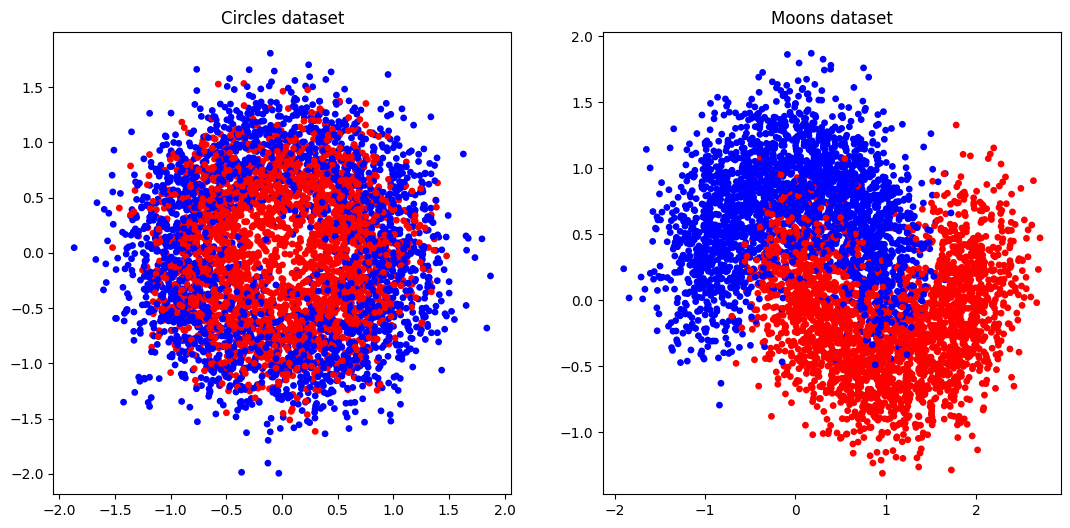

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='bwr', s=15)
axes[0].set_title("Circles dataset")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='bwr', s=15)
axes[1].set_title("Moons dataset")

plt.show()


**Circles metrics**

In [12]:
r = np.sqrt(X_circles[:, 0]**2 + X_circles[:, 1]**2)

r0 = r[y_circles == 0]
r1 = r[y_circles == 1]

hist_bins = 100
p0, bins = np.histogram(r0, bins=hist_bins, density=True)
p1, _ = np.histogram(r1, bins=bins, density=True)

bin_width = bins[1] - bins[0]
overlap = np.sum(np.minimum(p0, p1)) * bin_width

bayes_error = 0.5 * overlap
bayes_accuracy = 1 - bayes_error

r_threshold = (r0.mean() + r1.mean()) / 2
margin = np.abs(r - r_threshold)

mean_margin = margin.mean()
std_margin = margin.std()
near_boundary_ratio = np.mean(margin < 0.1)

var0 = np.var(r0)
var1 = np.var(r1)

fisher_ratio = (r0.mean() - r1.mean())**2 / (var0 + var1)

metrics_df = pd.DataFrame({
    "radial_overlap": [overlap],
    "bayes_error_approx": [bayes_error],
    "bayes_accuracy_upper_bound": [bayes_accuracy],
    "mean_margin": [mean_margin],
    "std_margin": [std_margin],
    "near_boundary_fraction_<0.1": [near_boundary_ratio],
    "class0_radial_variance": [var0],
    "class1_radial_variance": [var1],
    "fisher_ratio": [fisher_ratio]
})

metrics_df.index = ["Circles_distribution_metrics"]
metrics_df = metrics_df.T

metrics_df

,Circles_distribution_metrics
radial_overlap,0.615179
bayes_error_approx,0.307589
bayes_accuracy_upper_bound,0.692411
mean_margin,0.254597
std_margin,0.187073
near_boundary_fraction_<0.1,0.237600
class0_radial_variance,0.081386
class1_radial_variance,0.079419
fisher_ratio,0.482906


**Moons metrics** 

In [13]:
from sklearn.neighbors import KernelDensity
from sklearn.svm import SVC


svm_rbf = SVC(kernel='rbf', gamma='scale', probability=True)
svm_rbf.fit(X_moons_train, y_moons_train)

margin = np.abs(svm_rbf.decision_function(X_circles))  # np.abs для расстояния до границы

def kde_overlap(X, y, bandwidth=0.2, grid_size=100):
    X0 = X[y == 0]
    X1 = X[y == 1]

    kde0 = KernelDensity(bandwidth=bandwidth).fit(X0)
    kde1 = KernelDensity(bandwidth=bandwidth).fit(X1)

    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size)
    )
    grid = np.vstack([xx.ravel(), yy.ravel()]).T

    p0 = np.exp(kde0.score_samples(grid))
    p1 = np.exp(kde1.score_samples(grid))

    overlap = np.sum(np.minimum(p0, p1)) / grid_size**2
    return overlap

overlap = kde_overlap(X_moons, y_moons)


bayes_error = 0.5 * overlap
bayes_accuracy = 1 - bayes_error


mean_margin = margin.mean()
std_margin = margin.std()
near_boundary_ratio = np.mean(margin < 0.1)

var0_x = np.var(X_circles[y_circles==0,0])
var0_y = np.var(X_circles[y_circles==0,1])
var1_x = np.var(X_circles[y_circles==1,0])
var1_y = np.var(X_circles[y_circles==1,1])

mean0 = X_circles[y_circles==0].mean(axis=0)
mean1 = X_circles[y_circles==1].mean(axis=0)
fisher_ratio = np.sum((mean0 - mean1)**2) / (var0_x+var0_y+var1_x+var1_y)


metrics_df_moons = pd.DataFrame({
    "kde_overlap": [overlap],
    "bayes_error_approx": [bayes_error],
    "bayes_accuracy_upper_bound": [bayes_accuracy],
    "mean_margin": [mean_margin],
    "std_margin": [std_margin],
    "near_boundary_fraction_<0.1": [near_boundary_ratio],
    "class0_variance_sum": [var0_x + var0_y],
    "class1_variance_sum": [var1_x + var1_y],
    "fisher_ratio": [fisher_ratio]
})

metrics_df_moons.index = ["Moons_distribution_metrics"]
metrics_df_moons_T = metrics_df_moons.T
metrics_df_moons_T

,Moons_distribution_metrics
kde_overlap,0.015906
bayes_error_approx,0.007953
bayes_accuracy_upper_bound,0.992047
mean_margin,0.939385
std_margin,0.468910
near_boundary_fraction_<0.1,0.041800
class0_variance_sum,1.175821
class1_variance_sum,0.668441
fisher_ratio,0.000037


### Variational Quantum Classifiers

**Circles**

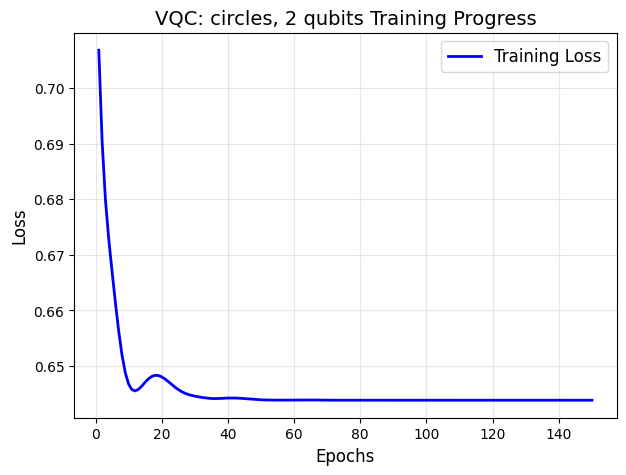

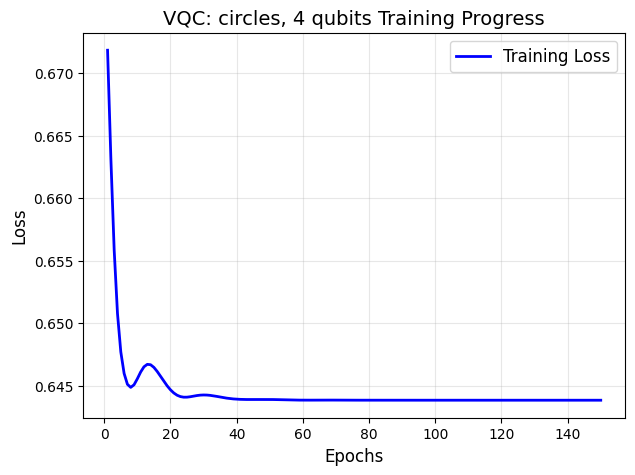

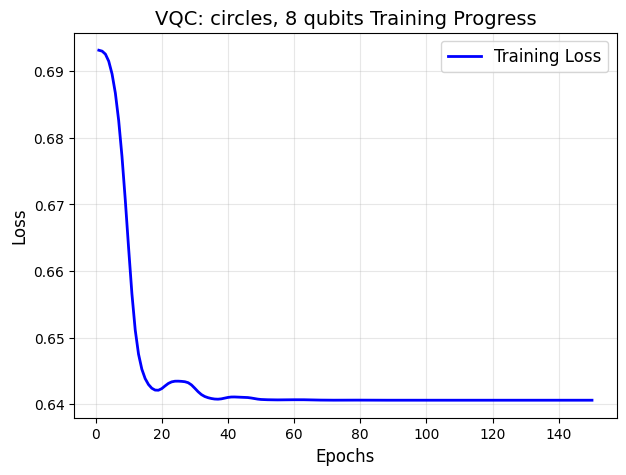

In [14]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_circles = VQC(n_qubits=q)

    losses = vqc_circles.fit(X_circles_train, y_circles_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_circles, X_circles_train, y_circles_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC",
        "Dataset": "Circles",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'VQC: circles, {q} qubits Training Progress')

**Moons**

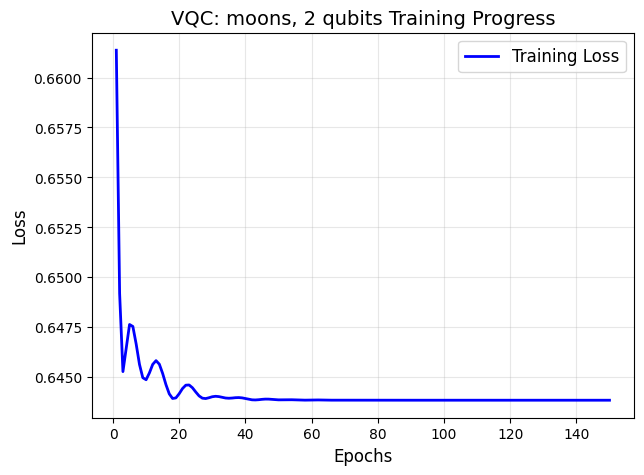

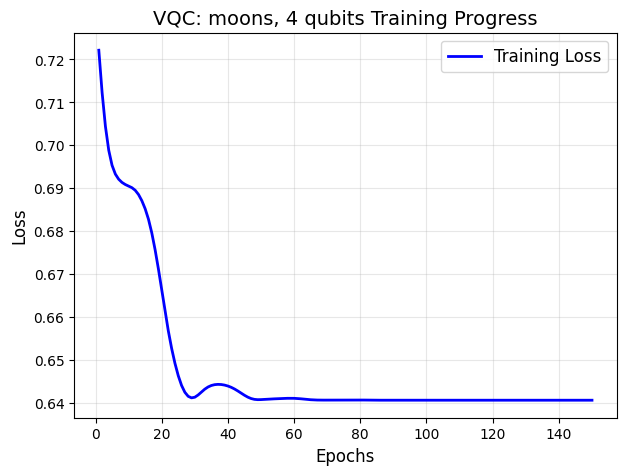

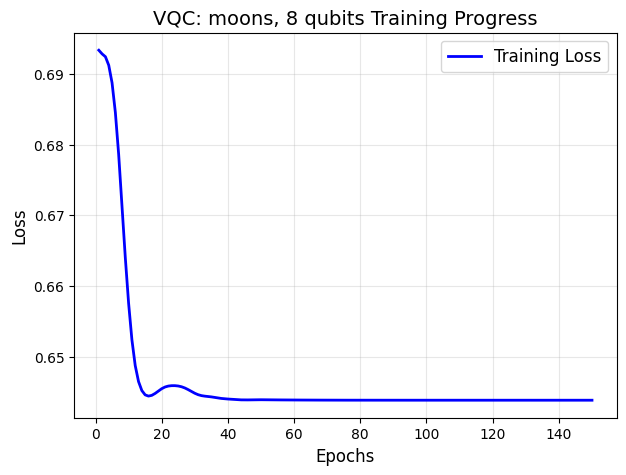

In [15]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_moons = VQC(n_qubits=q)

    losses = vqc_moons.fit(X_moons_train, y_moons_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_moons, X_moons_train, y_moons_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC",
        "Dataset": "Moons",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'VQC: moons, {q} qubits Training Progress')


### Hybrid Variational Quantum Classifiers

**Circles** 

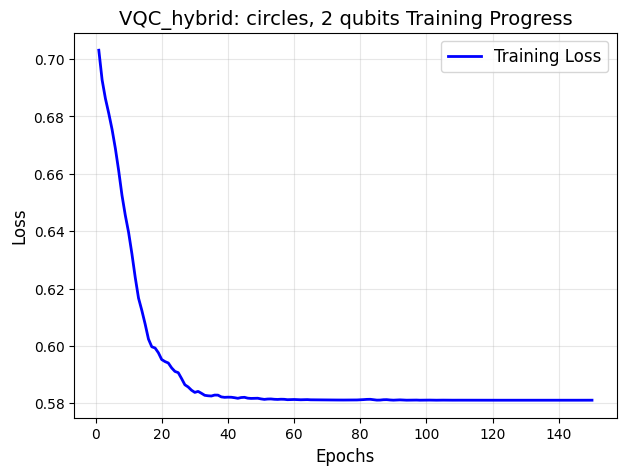

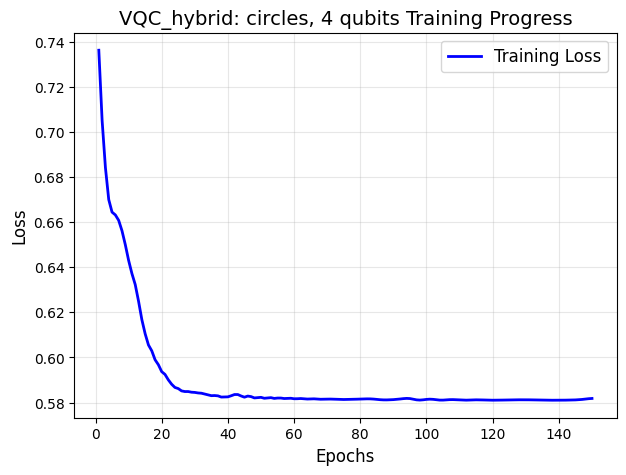

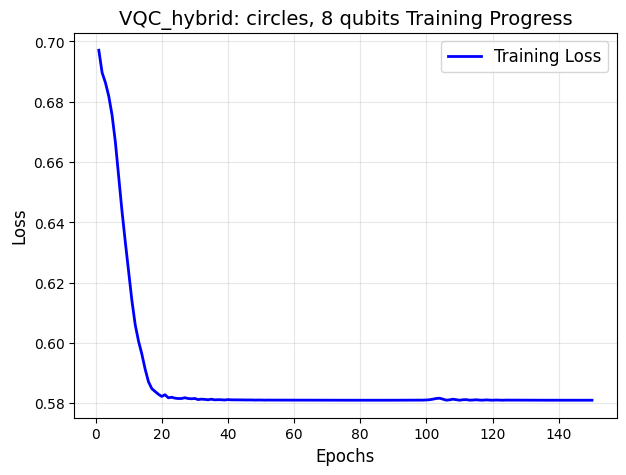

In [16]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_hybrid_circles = VQC_hybrid(n_qubits=q)

    losses = vqc_hybrid_circles.fit(X_circles_train, y_circles_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_hybrid_circles, X_circles_train, y_circles_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC_hybrid",
        "Dataset": "Circles",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'VQC_hybrid: circles, {q} qubits Training Progress')

**Moons**

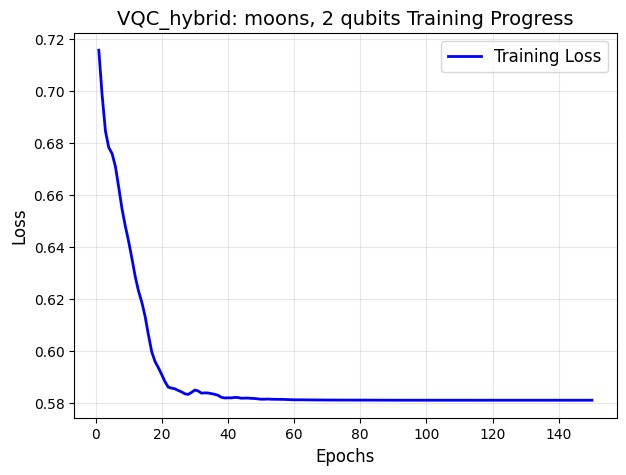

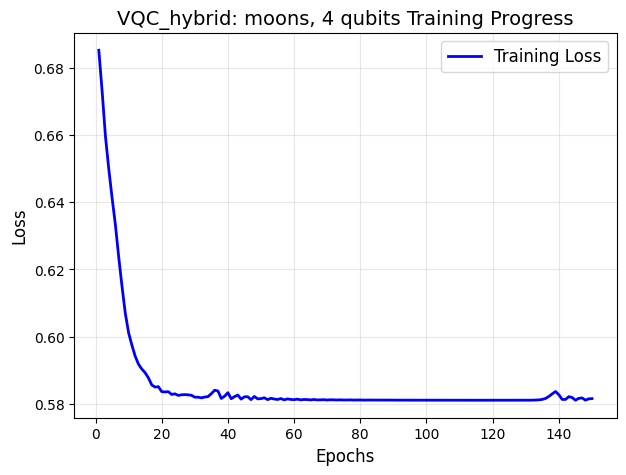

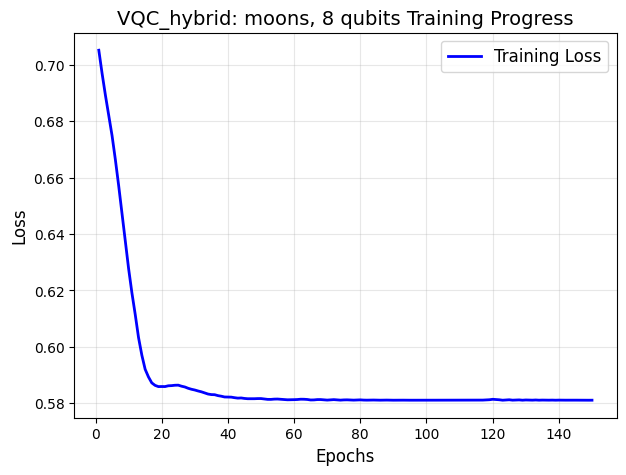

In [17]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_hybrid_moons = VQC_hybrid(n_qubits=q)

    losses = vqc_hybrid_moons.fit(X_moons_train, y_moons_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_hybrid_moons, X_moons_train, y_moons_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC_hybrid",
        "Dataset": "Moons",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'VQC_hybrid: moons, {q} qubits Training Progress')

### MLP

**Circles**

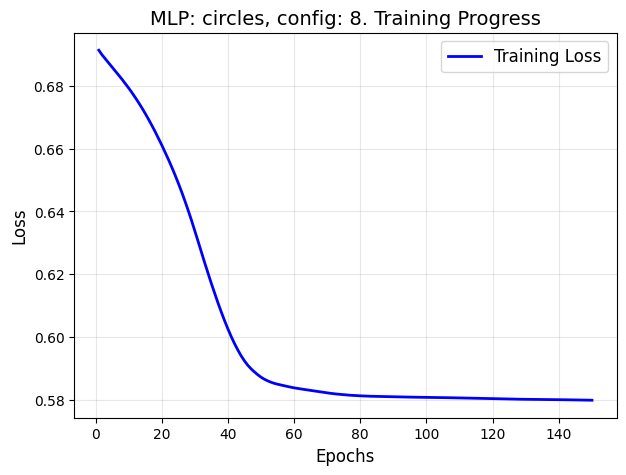

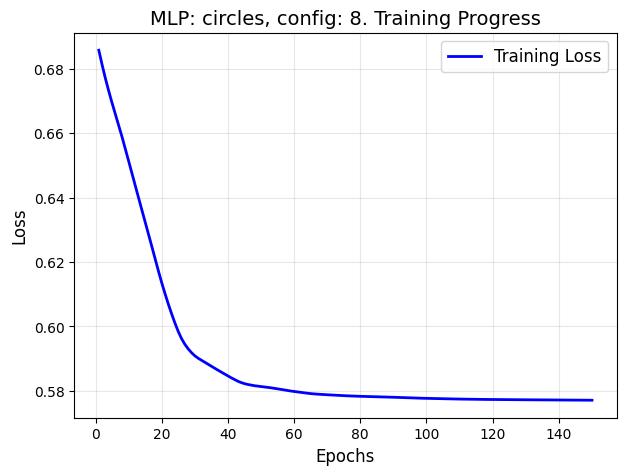

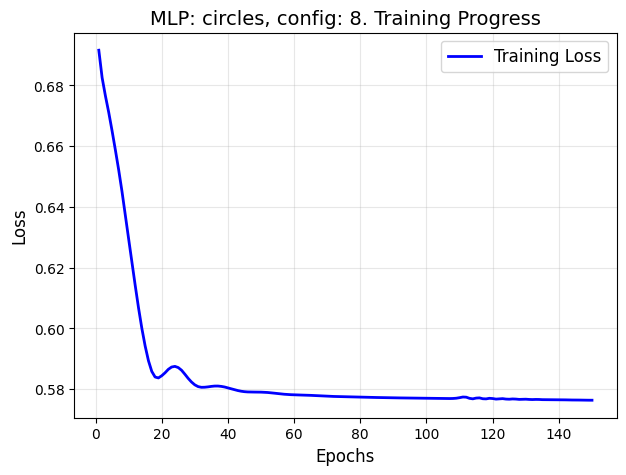

In [18]:
mlp_configs = [
    [8, 8],      # 2 слоя по 8 нейронов
    [16, 16],    # 2 слоя по 16 нейронов
    [32, 32]     # 2 слоя по 32 нейронов
]


for config in mlp_configs:
    mlp_circles = MLP(input_dim=X_circles_train.shape[1], hidden_dims=config)

    losses = mlp_circles.fit(X_circles_train, y_circles_train, epochs=150)

    grads, grad_norm, grad_var = compute_gradients(mlp_circles, X_circles_train, y_circles_train)
    grad_mean = grads.mean()


    results.append({
        "Model": "MLP",
        "Dataset": "Circles",
        "n_qubits": None,
        "Hidden_Layers": str(config),
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'MLP: circles, config: {q}. Training Progress')

**Moons**

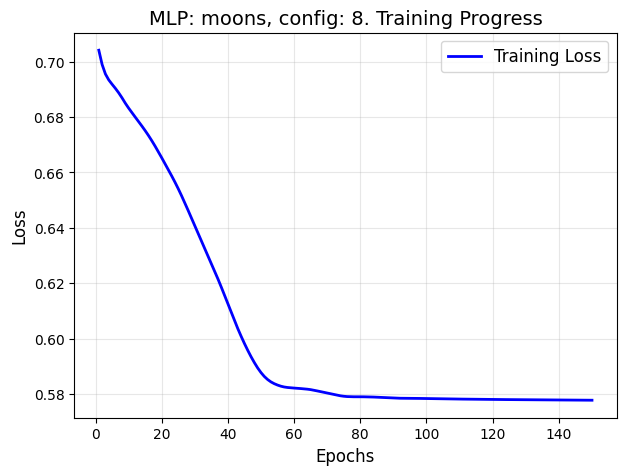

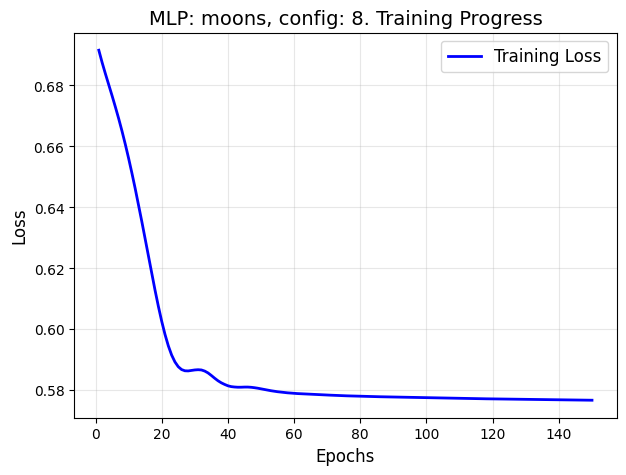

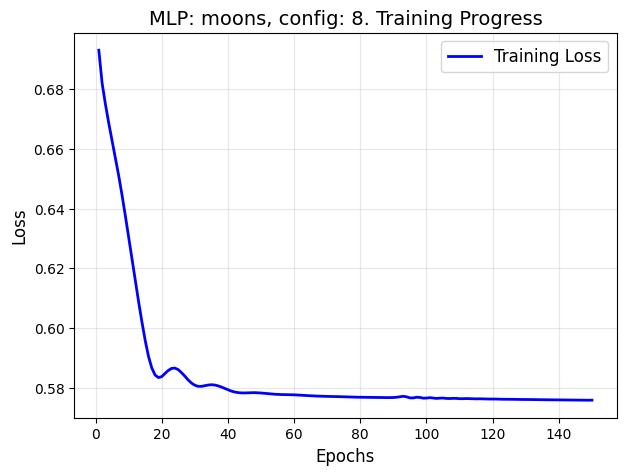

In [19]:
mlp_configs = [
    [8, 8],      # 2 слоя по 8 нейронов
    [16, 16],    # 2 слоя по 16 нейронов
    [32, 32]     # 2 слоя по 32 нейронов
]


for config in mlp_configs:
    mlp_moons = MLP(input_dim=X_moons_train.shape[1], hidden_dims=config)

    losses = mlp_moons.fit(X_moons_train, y_moons_train, epochs=150)

    grads, grad_norm, grad_var = compute_gradients(mlp_moons, X_moons_train, y_moons_train)
    grad_mean = grads.mean()


    results.append({
        "Model": "MLP",
        "Dataset": "Moons",
        "n_qubits": None,
        "Hidden_Layers": str(config),
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

    training_plot(losses, f'MLP: moons, config: {q}. Training Progress')

### Analysis of the results

In [30]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by=["Dataset"]
)

df_results

,Model,Dataset,n_qubits,Hidden_Layers,Loss_final,Gradient_Norm,Gradient_Variance,Gradient_Mean
0,VQC,Circles,2.0,NaN,0.643854,0.000011,1.083137e-11,6.785852e-07
14,MLP,Circles,NaN,"[32, 32]",0.576346,0.012880,1.400773e-07,-6.302984e-06
13,MLP,Circles,NaN,"[16, 16]",0.577096,0.001463,6.367018e-09,2.077032e-07
12,MLP,Circles,NaN,"[8, 8]",0.579877,0.002295,4.892205e-08,-4.110860e-05
7,VQC_hybrid,Circles,4.0,NaN,0.581827,0.068465,1.116210e-04,2.329940e-03
6,VQC_hybrid,Circles,2.0,NaN,0.581051,0.007029,2.300784e-06,-4.017657e-04
8,VQC_hybrid,Circles,8.0,NaN,0.581045,0.002505,7.681543e-08,-4.035640e-05
2,VQC,Circles,8.0,NaN,0.640622,0.000019,7.523804e-12,-7.158106e-08
1,VQC,Circles,4.0,NaN,0.643856,0.000011,5.088306e-12,4.274330e-07
4,VQC,Moons,4.0,NaN,0.640622,0.000041,7.102608e-11,-1.605114e-06


### Additional Diagnostics for Barren Plateaus

На предыдущем этапе были обучены базовые модели `VQC`, `VQC_hybrid` и `MLP`, а также сохранены итоговые значения функции потерь и градиентов. Однако для анализа Barren Plateaus недостаточно смотреть только на финальную норму градиента. Необходимо отслеживать динамику обучения по эпохам: изменение функции потерь, нормы градиента и дисперсии градиента.

Проблема Barren Plateaus проявляется в том, что градиенты параметров вариационной квантовой схемы становятся близкими к нулю. В результате оптимизатор перестаёт получать полезный сигнал для обновления параметров.

Формально это можно описать через математическое ожидание градиента функции стоимости:

$$
\mathbb{E}_{\theta}\left[\frac{\partial C(\theta)}{\partial \theta_i}\right] \approx 0
$$

где:

- $C(\theta)$ — функция стоимости, например binary cross-entropy loss;
- $\theta$ — вектор обучаемых параметров квантовой схемы;
- $\theta_i$ — отдельный параметр квантовой схемы;
- $\frac{\partial C(\theta)}{\partial \theta_i}$ — градиент функции стоимости по параметру $\theta_i$;
- $\mathbb{E}_{\theta}$ — усреднение по случайным инициализациям параметров.

Также важна не только средняя величина градиента, но и его дисперсия:

$$
\mathrm{Var}\left[\frac{\partial C(\theta)}{\partial \theta_i}\right] \rightarrow 0
$$

Если дисперсия градиента стремится к нулю, то разные параметры получают почти одинаково малый обучающий сигнал. Это означает, что поверхность ошибки становится практически плоской для оптимизатора.

### Feature Preparation for Quantum Circuits

Исходные датасеты `Circles` и `Moons` имеют только два признака. При этом в эксперименте используются квантовые схемы с 2, 4 и 8 кубитами. Если число признаков меньше числа кубитов, часть кубитов не получает содержательного входного сигнала. Это может дополнительно ухудшать обучение и усиливать эффект деградации при увеличении числа кубитов.

Поэтому добавим отдельную функцию подготовки признаков. Она расширяет двумерное пространство признаков до нужного числа кубитов и нормирует значения в диапазон углов $[-\pi, \pi]$, так как `AngleEmbedding` интерпретирует входные данные как углы вращений.

Нормализация входных признаков выполняется следующим образом:

$$
x' = a + \frac{(x - x_{\min})(b - a)}{x_{\max} - x_{\min}}
$$

где:

- $x$ — исходное значение признака;
- $x'$ — нормализованное значение признака;
- $x_{\min}$ — минимальное значение признака в обучающей выборке;
- $x_{\max}$ — максимальное значение признака в обучающей выборке;
- $a = -\pi$ — нижняя граница диапазона;
- $b = \pi$ — верхняя граница диапазона.

После такой нормализации входные данные становятся согласованы с угловым кодированием в квантовой схеме.

In [31]:
X_moons_train_raw, X_moons_test_raw, y_moons_train, y_moons_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.3,
    random_state=42
)

scaler_moons_fixed = StandardScaler()

X_moons_train = scaler_moons_fixed.fit_transform(X_moons_train_raw)
X_moons_test = scaler_moons_fixed.transform(X_moons_test_raw)

In [32]:
def expand_features_for_qubits(X, n_qubits):
    x1 = X[:, 0]
    x2 = X[:, 1]

    features = [
        x1,
        x2,
        x1 ** 2,
        x2 ** 2,
        x1 * x2,
        np.sqrt(x1 ** 2 + x2 ** 2),
        np.sin(x1),
        np.cos(x1),
        np.sin(x2),
        np.cos(x2)
    ]

    X_new = np.column_stack(features)

    if X_new.shape[1] < n_qubits:
        repeat_count = int(np.ceil(n_qubits / X_new.shape[1]))
        X_new = np.tile(X_new, (1, repeat_count))

    return X_new[:, :n_qubits]


def prepare_quantum_features(X_train, X_test, n_qubits):
    X_train_expanded = expand_features_for_qubits(X_train, n_qubits)
    X_test_expanded = expand_features_for_qubits(X_test, n_qubits)

    scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))

    X_train_scaled = scaler.fit_transform(X_train_expanded)
    X_test_scaled = scaler.transform(X_test_expanded)

    return X_train_scaled, X_test_scaled

### Gradient Logging During Training

В старой реализации метод `fit` возвращает только значения функции потерь. Для анализа Barren Plateaus добавим отдельную функцию обучения, которая не меняет классы `VQC` и `VQC_hybrid`, но позволяет сохранить расширенную информацию о градиентах.

Будем логировать следующие величины:

$$
\|\nabla C(\theta)\|_2 = \sqrt{\sum_{i=1}^{m}\left(\frac{\partial C(\theta)}{\partial \theta_i}\right)^2}
$$

где:

- $\|\nabla C(\theta)\|_2$ — евклидова норма градиента;
- $C(\theta)$ — функция стоимости;
- $\theta_i$ — отдельный обучаемый параметр квантовой схемы;
- $m$ — общее число обучаемых параметров;
- $\frac{\partial C(\theta)}{\partial \theta_i}$ — производная функции стоимости по параметру $\theta_i$.

Также будем отслеживать дисперсию градиентов:

$$
\mathrm{Var}(g) = \frac{1}{m}\sum_{i=1}^{m}(g_i - \bar{g})^2
$$

где:

- $g_i$ — значение градиента для параметра $\theta_i$;
- $\bar{g}$ — среднее значение градиентов;
- $m$ — число параметров.

Если при увеличении числа кубитов loss перестаёт снижаться, а $\|\nabla C(\theta)\|_2$ и $\mathrm{Var}(g)$ становятся близкими к нулю, это является практическим признаком Barren Plateau.

In [33]:
def get_grad_stats(model):
    grads = []

    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.detach().flatten())

    if len(grads) == 0:
        return {
            "grad_norm": 0.0,
            "grad_var": 0.0,
            "grad_mean_abs": 0.0,
            "grad_max_abs": 0.0
        }

    grads = torch.cat(grads)

    return {
        "grad_norm": torch.norm(grads).item(),
        "grad_var": torch.var(grads).item(),
        "grad_mean_abs": torch.mean(torch.abs(grads)).item(),
        "grad_max_abs": torch.max(torch.abs(grads)).item()
    }


def fit_with_gradient_logging(model, X_train, y_train, epochs=150, lr=0.1, optimizer_name="adam"):
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'")

    loss_fn = torch.nn.BCELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)

    history = {
        "loss": [],
        "grad_norm": [],
        "grad_var": [],
        "grad_mean_abs": [],
        "grad_max_abs": []
    }

    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        preds = model(X_train_t).squeeze()
        loss = loss_fn(preds, y_train_t)

        loss.backward()

        grad_stats = get_grad_stats(model)

        optimizer.step()

        history["loss"].append(loss.item())
        history["grad_norm"].append(grad_stats["grad_norm"])
        history["grad_var"].append(grad_stats["grad_var"])
        history["grad_mean_abs"].append(grad_stats["grad_mean_abs"])
        history["grad_max_abs"].append(grad_stats["grad_max_abs"])

        if epoch % 50 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"loss={loss.item():.5f} | "
                f"grad_norm={grad_stats['grad_norm']:.3e} | "
                f"grad_var={grad_stats['grad_var']:.3e}"
            )

    return history

### Training Dynamics Visualization

Для диагностики Barren Plateaus построим три основных графика:

1. график функции потерь по эпохам;
2. график нормы градиента по эпохам;
3. график дисперсии градиента по эпохам.

Если модель попадает в Barren Plateau, то функция потерь выходит на плато, а значения нормы и дисперсии градиента падают до очень малых величин

In [34]:
def plot_barren_plateau_diagnostics(history, title):
    epochs = np.arange(1, len(history["loss"]) + 1)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["loss"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss dynamics")
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["grad_norm"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Gradient norm")
    plt.yscale("log")
    plt.title("Gradient norm dynamics")
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["grad_var"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Gradient variance")
    plt.yscale("log")
    plt.title("Gradient variance dynamics")
    plt.grid(alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Baseline VQC Diagnostics

Теперь повторим обучение базовой квантовой модели `VQC`, но уже с логированием градиентов по эпохам. Это не заменяет старый эксперимент, а добавляет к нему диагностический слой.

Особое внимание уделяется сравнению схем при $n = 2$, $n = 4$ и $n = 8$, где $n$ — число кубитов. Если при увеличении $n$ норма градиента уменьшается, а функция потерь перестает снижаться, это указывает на деградацию обучаемости квантовой схемы


Dataset: Circles | Model: VQC | Qubits: 2
Epoch 000 | loss=0.69650 | grad_norm=6.096e-02 | grad_var=3.155e-04
Epoch 050 | loss=0.63366 | grad_norm=6.536e-03 | grad_var=3.757e-06
Epoch 100 | loss=0.63329 | grad_norm=6.039e-04 | grad_var=2.753e-08


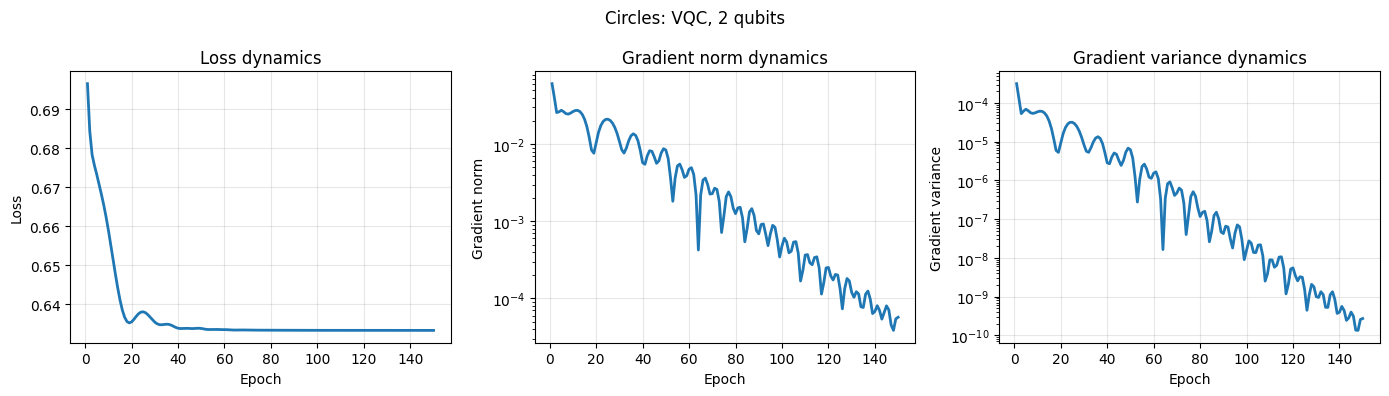


Dataset: Circles | Model: VQC | Qubits: 4
Epoch 000 | loss=0.69971 | grad_norm=3.412e-02 | grad_var=4.818e-05
Epoch 050 | loss=0.62407 | grad_norm=2.424e-03 | grad_var=2.556e-07
Epoch 100 | loss=0.62391 | grad_norm=3.595e-04 | grad_var=5.396e-09


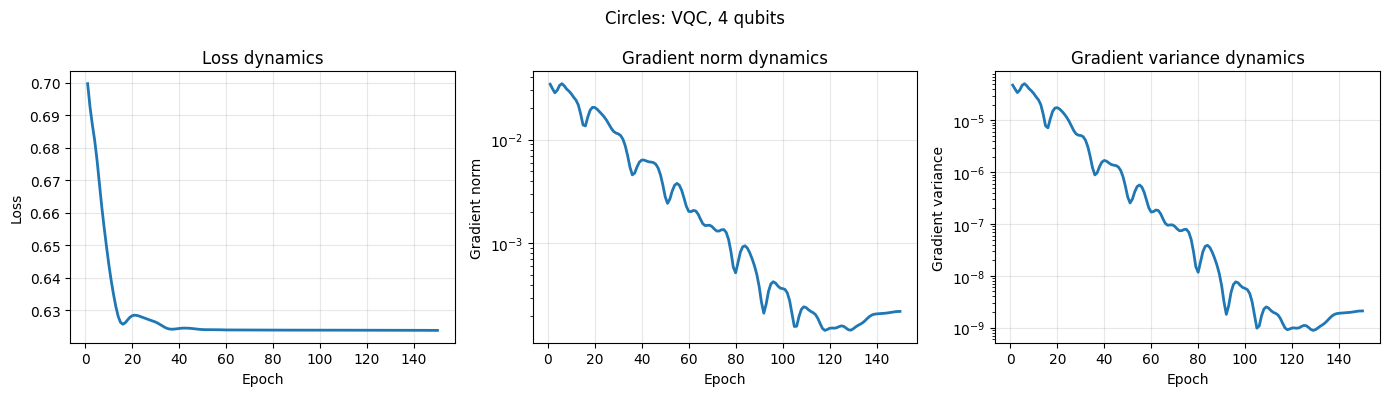


Dataset: Circles | Model: VQC | Qubits: 8
Epoch 000 | loss=0.69359 | grad_norm=3.108e-03 | grad_var=1.836e-07
Epoch 050 | loss=0.67282 | grad_norm=1.514e-03 | grad_var=4.847e-08
Epoch 100 | loss=0.67014 | grad_norm=1.327e-03 | grad_var=3.704e-08


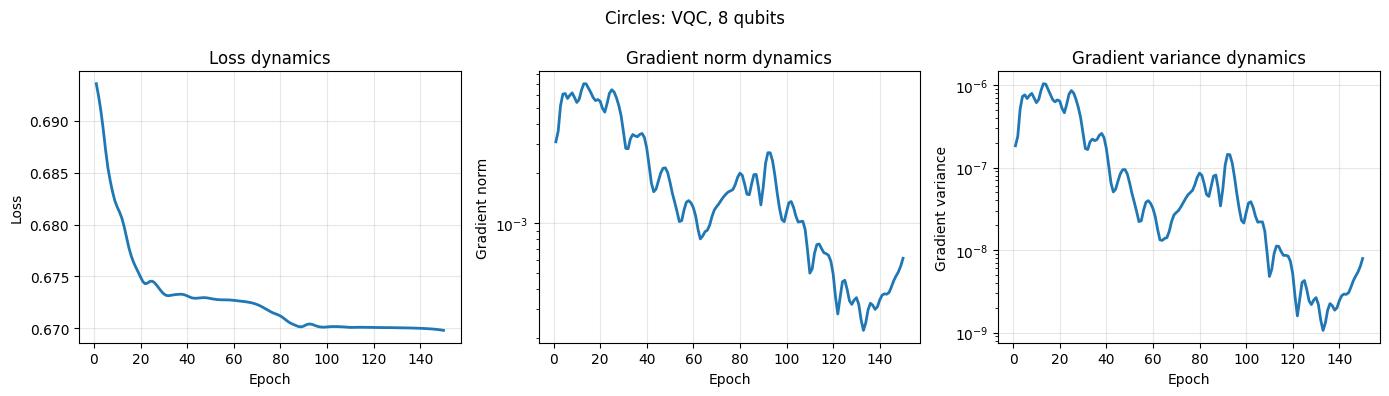


Dataset: Moons | Model: VQC | Qubits: 2
Epoch 000 | loss=0.80507 | grad_norm=1.988e-01 | grad_var=3.379e-03
Epoch 050 | loss=0.53269 | grad_norm=3.709e-02 | grad_var=1.239e-04
Epoch 100 | loss=0.52804 | grad_norm=1.476e-03 | grad_var=1.966e-07


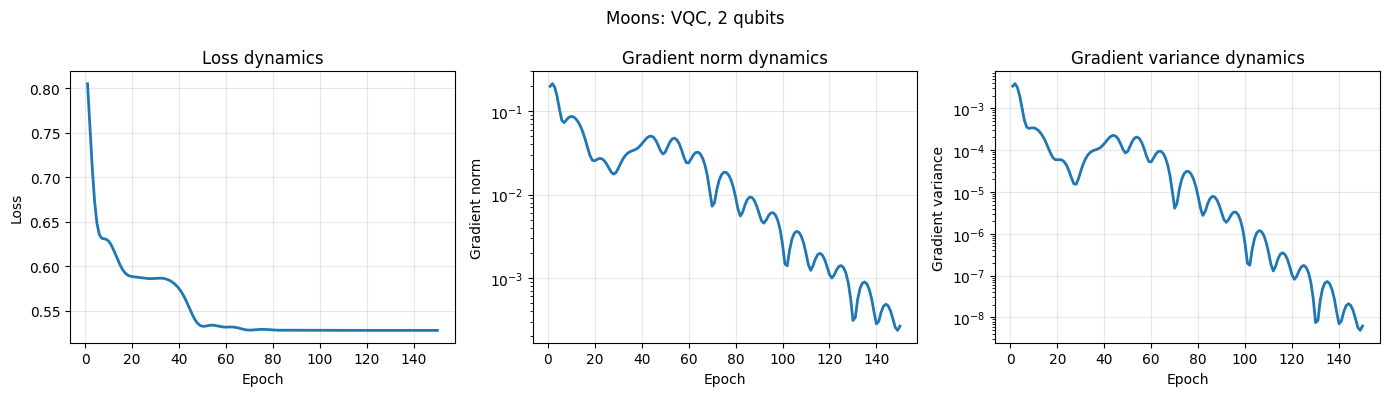


Dataset: Moons | Model: VQC | Qubits: 4
Epoch 000 | loss=0.69582 | grad_norm=2.998e-02 | grad_var=3.771e-05
Epoch 050 | loss=0.57487 | grad_norm=6.492e-03 | grad_var=1.826e-06
Epoch 100 | loss=0.57458 | grad_norm=5.734e-04 | grad_var=1.333e-08


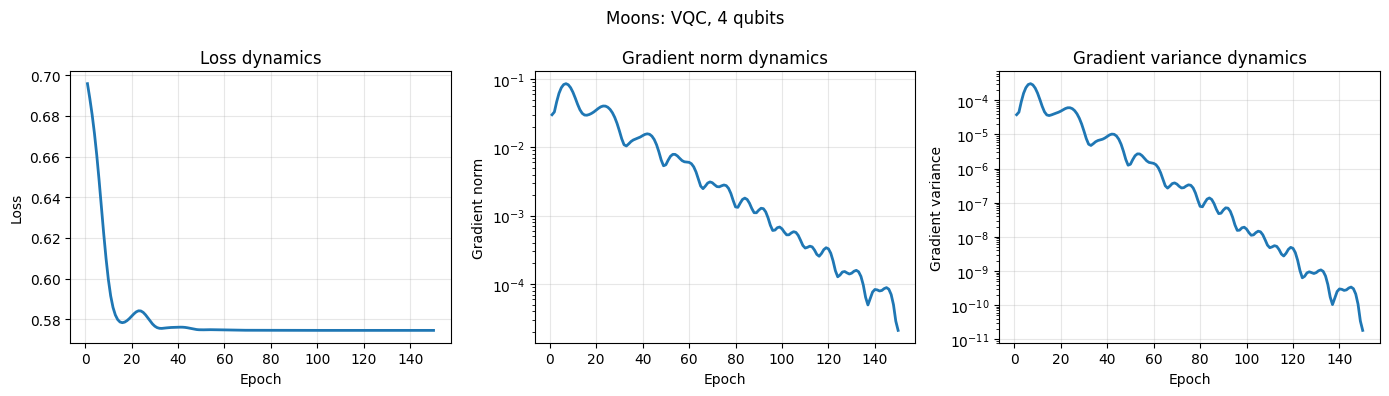


Dataset: Moons | Model: VQC | Qubits: 8
Epoch 000 | loss=0.69989 | grad_norm=1.658e-02 | grad_var=5.675e-06
Epoch 050 | loss=0.64538 | grad_norm=3.328e-03 | grad_var=2.344e-07
Epoch 100 | loss=0.64090 | grad_norm=1.039e-03 | grad_var=2.296e-08


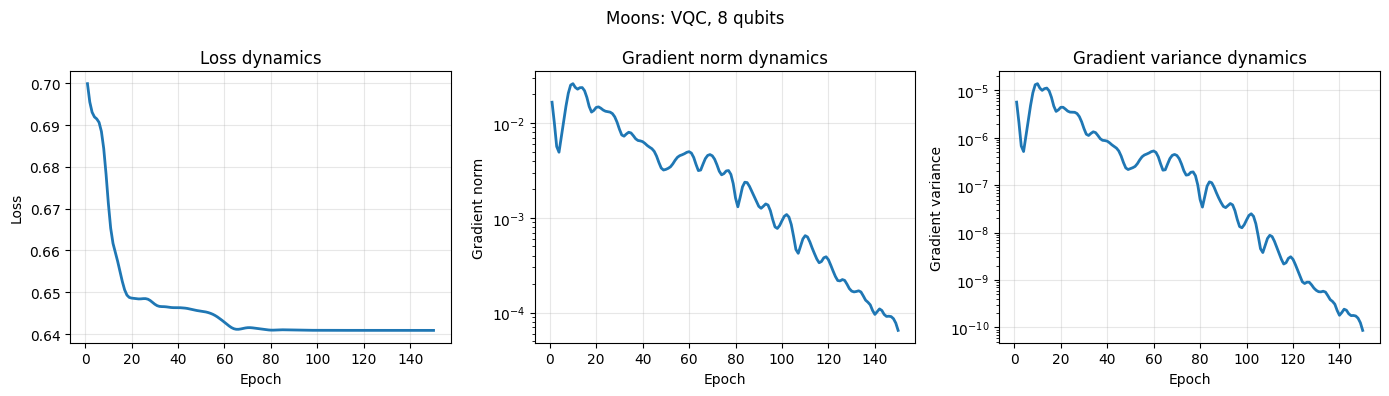

In [35]:
diagnostic_results = []
diagnostic_histories = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("Circles", X_circles_train, X_circles_test, y_circles_train, y_circles_test),
    ("Moons", X_moons_train, X_moons_test, y_moons_train, y_moons_test)
]:
    for q in [2, 4, 8]:
        print(f"\nDataset: {dataset_name} | Model: VQC | Qubits: {q}")

        X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, q)

        model = VQC(n_qubits=q)

        history = fit_with_gradient_logging(
            model,
            X_train_q,
            y_train,
            epochs=150,
            lr=0.1,
            optimizer_name="adam"
        )

        y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
        y_pred = (y_pred > 0.5).astype(int)

        diagnostic_results.append({
            "Dataset": dataset_name,
            "Model": "VQC_diagnostic",
            "n_qubits": q,
            "Final_Loss": history["loss"][-1],
            "Mean_Last20_Grad_Norm": np.mean(history["grad_norm"][-20:]),
            "Mean_Last20_Grad_Var": np.mean(history["grad_var"][-20:]),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0)
        })

        key = f"{dataset_name}_VQC_{q}"
        diagnostic_histories[key] = history

        plot_barren_plateau_diagnostics(
            history,
            title=f"{dataset_name}: VQC, {q} qubits"
        )

In [36]:
diagnostic_df = pd.DataFrame(diagnostic_results)
diagnostic_df

,Dataset,Model,n_qubits,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,Circles,VQC_diagnostic,2,0.633277,0.000079,5.785085e-10,0.642000,0.619979,0.781818,0.691557
1,Circles,VQC_diagnostic,4,0.623844,0.000199,1.728009e-09,0.633333,0.613169,0.774026,0.684271
2,Circles,VQC_diagnostic,8,0.669791,0.000372,3.124384e-09,0.600667,0.595745,0.690909,0.639808
3,Moons,VQC_diagnostic,2,0.528026,0.000488,2.523734e-08,0.818000,0.829139,0.812987,0.820984
4,Moons,VQC_diagnostic,4,0.574581,0.000084,3.671120e-10,0.790000,0.806191,0.777922,0.791804
5,Moons,VQC_diagnostic,8,0.640869,0.000116,2.976703e-10,0.717333,0.752187,0.670130,0.708791


### Gradient Scaling with the Number of Qubits

Следующий график показывает, как средняя норма градиента за последние эпохи меняется при увеличении числа кубитов.

Для Barren Plateaus характерно экспоненциальное уменьшение дисперсии градиента с ростом числа кубитов. В упрощённом виде это можно записать так:

$$
\mathrm{Var}\left[\frac{\partial C(\theta)}{\partial \theta_i}\right] \sim \mathcal{O}\left(\frac{1}{2^n}\right)
$$

где:

- $\mathrm{Var}\left[\frac{\partial C(\theta)}{\partial \theta_i}\right]$ — дисперсия градиента по параметру $\theta_i$;
- $C(\theta)$ — функция стоимости;
- $\theta_i$ — параметр квантовой схемы;
- $n$ — число кубитов;
- $\mathcal{O}\left(\frac{1}{2^n}\right)$ — порядок убывания величины при росте $n$.

Это означает, что при увеличении числа кубитов оптимизатору становится всё сложнее находить направление полезного обновления параметров.

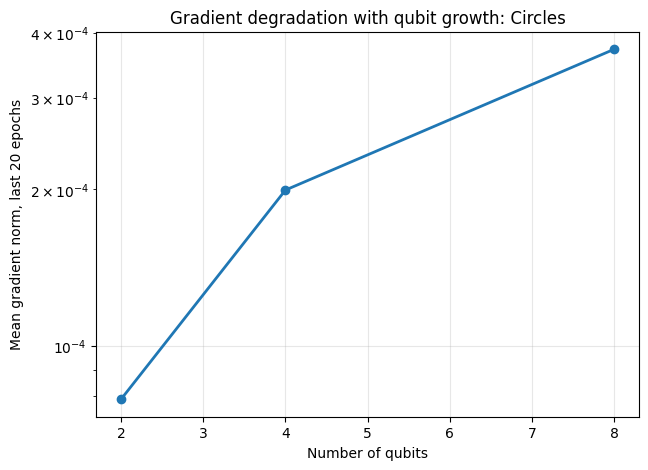

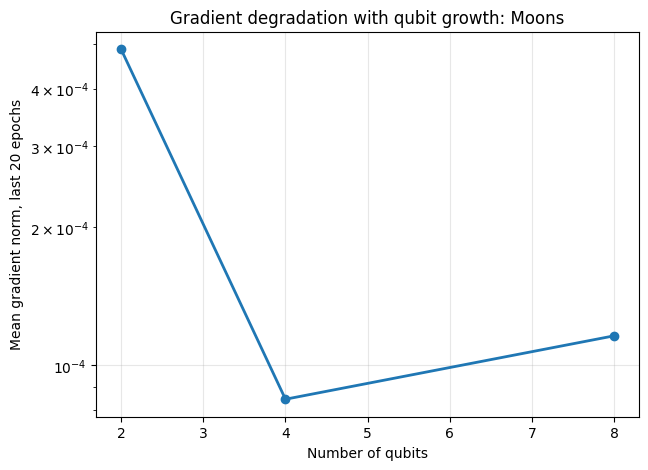

In [37]:
def plot_gradient_vs_qubits(df, dataset_name):
    part = df[df["Dataset"] == dataset_name].sort_values("n_qubits")

    plt.figure(figsize=(7, 5))
    plt.plot(
        part["n_qubits"],
        part["Mean_Last20_Grad_Norm"],
        marker="o",
        linewidth=2
    )
    plt.yscale("log")
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean gradient norm, last 20 epochs")
    plt.title(f"Gradient degradation with qubit growth: {dataset_name}")
    plt.grid(alpha=0.3)
    plt.show()


plot_gradient_vs_qubits(diagnostic_df, "Circles")
plot_gradient_vs_qubits(diagnostic_df, "Moons")

### Alternative Ansatz Architectures

Исходная модель использует `StronglyEntanglingLayers`. Такой Ansatz является выразительным, но при увеличении числа кубитов и глубины схемы может приводить к слишком сложному ландшафту оптимизации.

Поэтому добавим альтернативные схемы, не изменяя старый класс `VQC`.

Будут рассмотрены три варианта:

1. `strong` — схема на основе `StronglyEntanglingLayers`;
2. `basic` — более простая схема на основе `BasicEntanglingLayers`;
3. `ry_cz` — ручная схема с чередованием `RY` и `CZ`.

Общее состояние параметризованной квантовой схемы можно записать так:

$$
|\psi(\theta, x)\rangle = U(\theta)E(x)|0\rangle^{\otimes n}
$$

где:

- $|\psi(\theta, x)\rangle$ — итоговое квантовое состояние;
- $E(x)$ — операция кодирования входных данных;
- $x$ — входной объект;
- $U(\theta)$ — параметризованный Ansatz;
- $\theta$ — обучаемые параметры схемы;
- $|0\rangle^{\otimes n}$ — начальное состояние системы из $n$ кубитов.

Идея эксперимента состоит в том, чтобы проверить, сохраняют ли более простые схемы более устойчивые градиенты при росте числа кубитов.

In [40]:
class VQCAnsatz(nn.Module):
    def __init__(self, n_qubits=2, n_layers=2, ansatz_type="basic", dev_name="default.qubit", init_scale=0.01):
        super(VQCAnsatz, self).__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.ansatz_type = ansatz_type
        self.dev = qml.device(dev_name, wires=n_qubits)

        if ansatz_type == "strong":
            weight_shapes = {"weights": (n_layers, n_qubits, 3)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                qml.AngleEmbedding(inputs, wires=range(n_qubits))
                qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
                return qml.expval(qml.PauliZ(0))

        elif ansatz_type == "basic":
            weight_shapes = {"weights": (n_layers, n_qubits)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                qml.AngleEmbedding(inputs, wires=range(n_qubits))
                qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
                return qml.expval(qml.PauliZ(0))

        elif ansatz_type == "ry_cz":
            weight_shapes = {"weights": (n_layers, n_qubits)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                qml.AngleEmbedding(inputs, wires=range(n_qubits))

                for layer in range(n_layers):
                    for wire in range(n_qubits):
                        qml.RY(weights[layer, wire], wires=wire)

                    for wire in range(n_qubits - 1):
                        qml.CZ(wires=[wire, wire + 1])

                return qml.expval(qml.PauliZ(0))

        else:
            raise ValueError("ansatz_type must be 'strong', 'basic' or 'ry_cz'")

        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        with torch.no_grad():
            for param in self.quantum_layer.parameters():
                param.normal_(mean=0.0, std=init_scale)

        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

### Ansatz Comparison

Теперь сравним несколько вариантов квантовой схемы при одинаковом числе кубитов. Это позволит проверить гипотезу: более простые схемы могут обучаться стабильнее, потому что реже попадают в область исчезающих градиентов.

Для бинарной классификации выход модели можно интерпретировать как вероятность принадлежности к положительному классу:

$$
\hat{y} = \sigma(z)
$$

где:

- $\hat{y}$ — предсказанная вероятность класса 1;
- $\sigma$ — сигмоидная функция;
- $z$ — выход квантового слоя после измерения.

Функция потерь задаётся через binary cross-entropy:

$$
C(\theta) = -\frac{1}{N}\sum_{j=1}^{N}\left[y_j \log(\hat{y}_j) + (1 - y_j)\log(1 - \hat{y}_j)\right]
$$

где:

- $C(\theta)$ — функция стоимости;
- $N$ — число объектов в обучающей выборке;
- $y_j$ — истинная метка объекта;
- $\hat{y}_j$ — предсказанная вероятность класса 1;
- $\theta$ — параметры квантовой схемы.

In [41]:
ansatz_results = []
ansatz_histories = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("Circles", X_circles_train, X_circles_test, y_circles_train, y_circles_test),
    ("Moons", X_moons_train, X_moons_test, y_moons_train, y_moons_test)
]:
    for q in [2, 4, 8]:
        X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, q)

        for ansatz_type in ["ry_cz", "basic", "strong"]:
            print(f"\nDataset: {dataset_name} | Ansatz: {ansatz_type} | Qubits: {q}")

            model = VQCAnsatz(
                n_qubits=q,
                n_layers=2,
                ansatz_type=ansatz_type,
                init_scale=0.01
            )

            history = fit_with_gradient_logging(
                model,
                X_train_q,
                y_train,
                epochs=150,
                lr=0.05,
                optimizer_name="adam"
            )

            y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
            y_pred = (y_pred > 0.5).astype(int)

            ansatz_results.append({
                "Dataset": dataset_name,
                "Ansatz": ansatz_type,
                "n_qubits": q,
                "Final_Loss": history["loss"][-1],
                "Mean_Last20_Grad_Norm": np.mean(history["grad_norm"][-20:]),
                "Mean_Last20_Grad_Var": np.mean(history["grad_var"][-20:]),
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0)
            })

            key = f"{dataset_name}_{ansatz_type}_{q}"
            ansatz_histories[key] = history


Dataset: Circles | Ansatz: ry_cz | Qubits: 2
Epoch 000 | loss=0.68355 | grad_norm=2.056e-03 | grad_var=1.409e-06
Epoch 050 | loss=0.63585 | grad_norm=3.128e-03 | grad_var=3.261e-06
Epoch 100 | loss=0.63557 | grad_norm=2.813e-04 | grad_var=2.638e-08

Dataset: Circles | Ansatz: basic | Qubits: 2
Epoch 000 | loss=0.68341 | grad_norm=1.322e-02 | grad_var=4.407e-05
Epoch 050 | loss=0.67461 | grad_norm=3.082e-04 | grad_var=2.830e-08
Epoch 100 | loss=0.67461 | grad_norm=1.664e-04 | grad_var=7.663e-09

Dataset: Circles | Ansatz: strong | Qubits: 2
Epoch 000 | loss=0.63558 | grad_norm=8.467e-04 | grad_var=6.366e-08
Epoch 050 | loss=0.63329 | grad_norm=2.807e-04 | grad_var=5.450e-09
Epoch 100 | loss=0.63328 | grad_norm=4.836e-05 | grad_var=1.939e-10

Dataset: Circles | Ansatz: ry_cz | Qubits: 4
Epoch 000 | loss=0.68354 | grad_norm=2.476e-03 | grad_var=8.758e-07
Epoch 050 | loss=0.63585 | grad_norm=3.120e-03 | grad_var=1.389e-06
Epoch 100 | loss=0.63557 | grad_norm=2.797e-04 | grad_var=1.118e-08

In [42]:
ansatz_df = pd.DataFrame(ansatz_results)
ansatz_df

,Dataset,Ansatz,n_qubits,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,Circles,ry_cz,2,0.635570,0.000034,4.089549e-10,0.648667,0.626694,0.780519,0.695200
1,Circles,basic,2,0.674609,0.000023,1.613716e-10,0.605333,0.576329,0.872727,0.694215
2,Circles,strong,2,0.633276,0.000007,4.603475e-12,0.642000,0.619979,0.781818,0.691557
3,Circles,ry_cz,4,0.635571,0.000069,9.618392e-10,0.648667,0.626694,0.780519,0.695200
4,Circles,basic,4,0.650151,0.000103,1.628132e-09,0.619333,0.594672,0.811688,0.686436
5,Circles,strong,4,0.623977,0.000117,6.258775e-10,0.634000,0.613333,0.776623,0.685387
6,Circles,ry_cz,8,0.635570,0.000102,1.101650e-09,0.648667,0.626694,0.780519,0.695200
7,Circles,basic,8,0.648540,0.000084,4.898202e-10,0.652667,0.644264,0.722078,0.680955
8,Circles,strong,8,0.664717,0.000093,1.956732e-10,0.575333,0.607780,0.487013,0.540735
9,Moons,ry_cz,2,0.690785,0.000285,1.539262e-08,0.548000,0.578231,0.441558,0.500736


### Ansatz Gradient Comparison

Если `StronglyEntanglingLayers` демонстрирует более быстрое падение нормы градиента при росте числа кубитов, это подтверждает предположение о том, что слишком выразительный Ansatz может ухудшать обучаемость модели.

В данном эксперименте основной диагностической величиной является средняя норма градиента за последние эпохи:

$$
G_{\text{last}} = \frac{1}{K}\sum_{t=T-K+1}^{T}\|\nabla C_t(\theta)\|_2
$$

где:

- $G_{\text{last}}$ — средняя норма градиента на последних эпохах;
- $K$ — число последних эпох, по которым выполняется усреднение;
- $T$ — общее число эпох обучения;
- $\nabla C_t(\theta)$ — градиент функции стоимости на эпохе $t$;
- $\|\cdot\|_2$ — евклидова норма.

Если $G_{\text{last}}$ становится очень малым, модель практически перестаёт обновлять параметры.

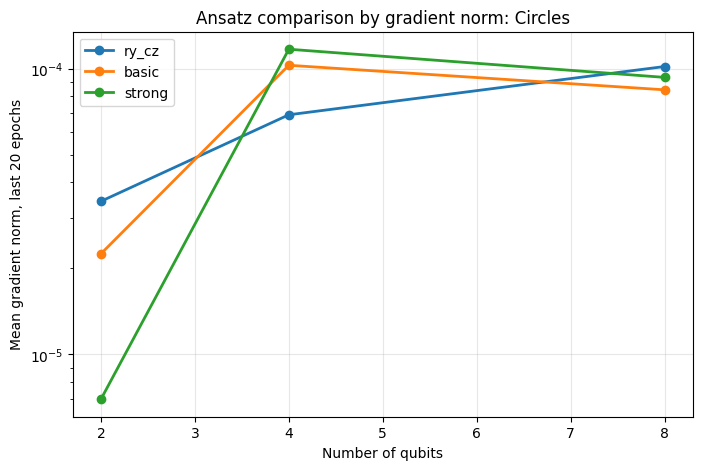

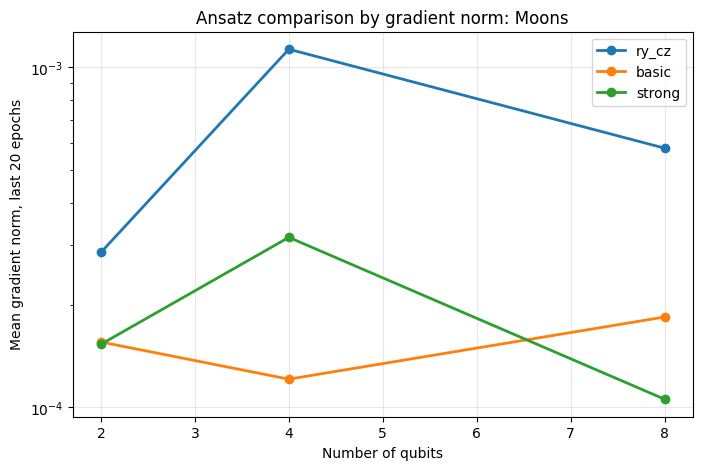

In [43]:
def plot_ansatz_gradient_comparison(df, dataset_name):
    part = df[df["Dataset"] == dataset_name]

    plt.figure(figsize=(8, 5))

    for ansatz_type in part["Ansatz"].unique():
        current = part[part["Ansatz"] == ansatz_type].sort_values("n_qubits")

        plt.plot(
            current["n_qubits"],
            current["Mean_Last20_Grad_Norm"],
            marker="o",
            linewidth=2,
            label=ansatz_type
        )

    plt.yscale("log")
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean gradient norm, last 20 epochs")
    plt.title(f"Ansatz comparison by gradient norm: {dataset_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


plot_ansatz_gradient_comparison(ansatz_df, "Circles")
plot_ansatz_gradient_comparison(ansatz_df, "Moons")

## Dynamic Ansatz Rebuilding

После диагностики можно сформулировать стратегию обхода Barren Plateaus. Вместо того чтобы заранее фиксировать сложную квантовую схему, модель начинает обучение с простой структуры. Далее схема изменяется в зависимости от поведения функции потерь и градиентов.

Для принятия решения используются две величины:

$$
\Delta C = \bar{C}_{prev} - \bar{C}_{curr}
$$

где:

- $\Delta C$ — улучшение функции потерь;
- $\bar{C}_{prev}$ — среднее значение loss на предыдущем окне эпох;
- $\bar{C}_{curr}$ — среднее значение loss на текущем окне эпох.

И средняя норма градиента:

$$
\bar{G} = \frac{1}{K}\sum_{t=T-K+1}^{T}\|\nabla C_t(\theta)\|_2
$$

где:

- $\bar{G}$ — средняя норма градиента на последних эпохах;
- $K$ — размер окна усреднения;
- $T$ — номер последней эпохи;
- $\nabla C_t(\theta)$ — градиент функции стоимости на эпохе $t$.

Если $\Delta C$ мало, но $\bar{G}$ остаётся достаточно большим, это означает, что модели может не хватать выразительности. В таком случае схему можно усложнить.

Если $\Delta C$ мало и $\bar{G}$ также близко к нулю, это указывает на Barren Plateau. В этом случае схему нельзя усложнять, потому что это может только усилить проблему. Вместо этого следует перейти к более простой и обучаемой структуре.

In [44]:
def detect_training_problem(history, loss_window=20, grad_threshold=1e-4, min_loss_improvement=1e-3):
    losses = np.array(history["loss"])
    grad_norms = np.array(history["grad_norm"])

    if len(losses) < loss_window * 2:
        return "not_enough_history"

    previous_loss = losses[-2 * loss_window:-loss_window].mean()
    current_loss = losses[-loss_window:].mean()

    loss_improvement = previous_loss - current_loss
    current_grad_norm = grad_norms[-loss_window:].mean()

    if loss_improvement < min_loss_improvement and current_grad_norm < grad_threshold:
        return "barren_plateau"

    if loss_improvement < min_loss_improvement and current_grad_norm >= grad_threshold:
        return "expressivity_limit"

    return "normal_training"

### Adaptive Ansatz Selection Algorithm

Добавим экспериментальную функцию, которая не меняет старые классы, а создаёт новые модели с разными схемами. Логика следующая:

1. начать с простой схемы `ry_cz`;
2. обучить модель несколько эпох;
3. определить режим обучения;
4. если возник Barren Plateau — оставить или упростить схему;
5. если не хватает выразительности — перейти к более сложной схеме;
6. сохранить историю пересборки.

Такой подход не гарантирует максимальное качество классификации в каждом запуске, но он делает процесс обучения более контролируемым и позволяет явно различать две причины ухудшения: исчезновение градиентов и недостаточную выразительность Ansatz.

In [45]:
def run_adaptive_ansatz_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name,
    n_qubits,
    epochs_per_stage=100,
    lr=0.05,
    grad_threshold=1e-4
):
    ansatz_sequence = ["ry_cz", "basic", "strong"]

    current_idx = 0
    current_layers = 1

    adaptive_history = {
        "loss": [],
        "grad_norm": [],
        "grad_var": [],
        "grad_mean_abs": [],
        "grad_max_abs": [],
        "stage": [],
        "ansatz": [],
        "layers": []
    }

    rebuild_log = []

    X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, n_qubits)

    for stage in range(3):
        current_ansatz = ansatz_sequence[current_idx]

        print(
            f"\nStage {stage} | "
            f"Dataset: {dataset_name} | "
            f"Qubits: {n_qubits} | "
            f"Ansatz: {current_ansatz} | "
            f"Layers: {current_layers}"
        )

        model = VQCAnsatz(
            n_qubits=n_qubits,
            n_layers=current_layers,
            ansatz_type=current_ansatz,
            init_scale=0.01
        )

        history = fit_with_gradient_logging(
            model,
            X_train_q,
            y_train,
            epochs=epochs_per_stage,
            lr=lr,
            optimizer_name="adam"
        )

        for key in ["loss", "grad_norm", "grad_var", "grad_mean_abs", "grad_max_abs"]:
            adaptive_history[key].extend(history[key])

        adaptive_history["stage"].extend([stage] * len(history["loss"]))
        adaptive_history["ansatz"].extend([current_ansatz] * len(history["loss"]))
        adaptive_history["layers"].extend([current_layers] * len(history["loss"]))

        problem_type = detect_training_problem(
            history,
            grad_threshold=grad_threshold
        )

        if problem_type == "normal_training":
            action = "keep_current_ansatz"
            rebuild_log.append({
                "stage": stage,
                "problem_type": problem_type,
                "action": action,
                "ansatz": current_ansatz,
                "layers": current_layers
            })
            break

        if problem_type == "expressivity_limit":
            if current_idx < len(ansatz_sequence) - 1:
                current_idx += 1
                action = f"switch_to_{ansatz_sequence[current_idx]}"
            else:
                current_layers += 1
                action = f"increase_layers_to_{current_layers}"

        elif problem_type == "barren_plateau":
            current_idx = max(0, current_idx - 1)
            current_layers = 1
            action = f"simplify_to_{ansatz_sequence[current_idx]}"

        else:
            action = "no_action"

        rebuild_log.append({
            "stage": stage,
            "problem_type": problem_type,
            "action": action,
            "ansatz": current_ansatz,
            "layers": current_layers
        })

        print(f"Detected problem: {problem_type}")
        print(f"Action: {action}")

    y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
    y_pred = (y_pred > 0.5).astype(int)

    final_result = {
        "Dataset": dataset_name,
        "Model": "AdaptiveAnsatzVQC",
        "n_qubits": n_qubits,
        "Final_Ansatz": current_ansatz,
        "Final_Layers": current_layers,
        "Final_Loss": adaptive_history["loss"][-1],
        "Mean_Last20_Grad_Norm": np.mean(adaptive_history["grad_norm"][-20:]),
        "Mean_Last20_Grad_Var": np.mean(adaptive_history["grad_var"][-20:]),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    }

    return final_result, adaptive_history, rebuild_log

### Adaptive Rebuilding Experiment

Теперь запустим адаптивную стратегию для разных датасетов и разного числа кубитов. Цель эксперимента — проверить, позволяет ли динамическая пересборка схемы удерживать градиенты от слишком быстрого исчезновения.

Важно отметить, что здесь оценивается не только итоговая accuracy или F1-score. Основной объект анализа — устойчивость процесса оптимизации.


Stage 0 | Dataset: Circles | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68358 | grad_norm=2.065e-05 | grad_var=2.132e-10
Epoch 050 | loss=0.67513 | grad_norm=3.329e-04 | grad_var=5.542e-08
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: Circles | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.68340 | grad_norm=1.310e-02 | grad_var=8.575e-05
Epoch 050 | loss=0.68250 | grad_norm=6.889e-04 | grad_var=2.373e-07
Detected problem: barren_plateau
Action: simplify_to_ry_cz

Stage 2 | Dataset: Circles | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68358 | grad_norm=1.514e-04 | grad_var=1.145e-08
Epoch 050 | loss=0.67513 | grad_norm=2.477e-04 | grad_var=3.068e-08
Detected problem: expressivity_limit
Action: switch_to_basic


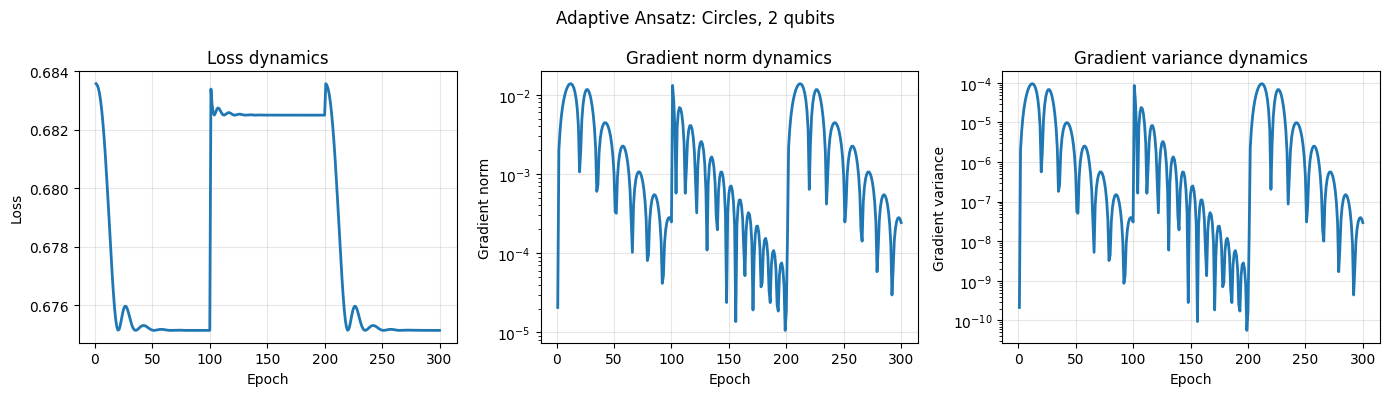


Stage 0 | Dataset: Circles | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68358 | grad_norm=1.811e-04 | grad_var=8.202e-09
Epoch 050 | loss=0.67513 | grad_norm=2.294e-04 | grad_var=1.316e-08
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: Circles | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.65007 | grad_norm=1.671e-02 | grad_var=8.734e-05
Epoch 050 | loss=0.64632 | grad_norm=8.787e-04 | grad_var=2.418e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: Circles | Qubits: 4 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.65009 | grad_norm=3.049e-04 | grad_var=7.475e-09
Epoch 050 | loss=0.64635 | grad_norm=5.474e-04 | grad_var=2.700e-08
Detected problem: barren_plateau
Action: simplify_to_basic


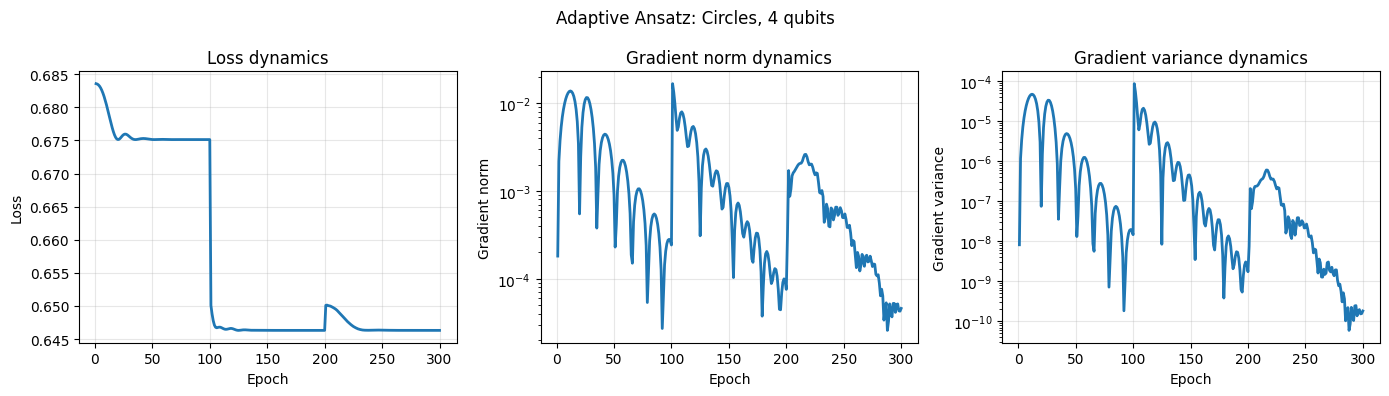


Stage 0 | Dataset: Circles | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68358 | grad_norm=2.443e-04 | grad_var=7.457e-09
Epoch 050 | loss=0.67513 | grad_norm=1.919e-04 | grad_var=4.601e-09
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: Circles | Qubits: 8 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.69107 | grad_norm=1.309e-02 | grad_var=2.000e-05
Epoch 050 | loss=0.67621 | grad_norm=2.037e-03 | grad_var=4.526e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: Circles | Qubits: 8 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.69105 | grad_norm=1.936e-04 | grad_var=1.624e-09
Epoch 050 | loss=0.67636 | grad_norm=2.426e-03 | grad_var=2.395e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


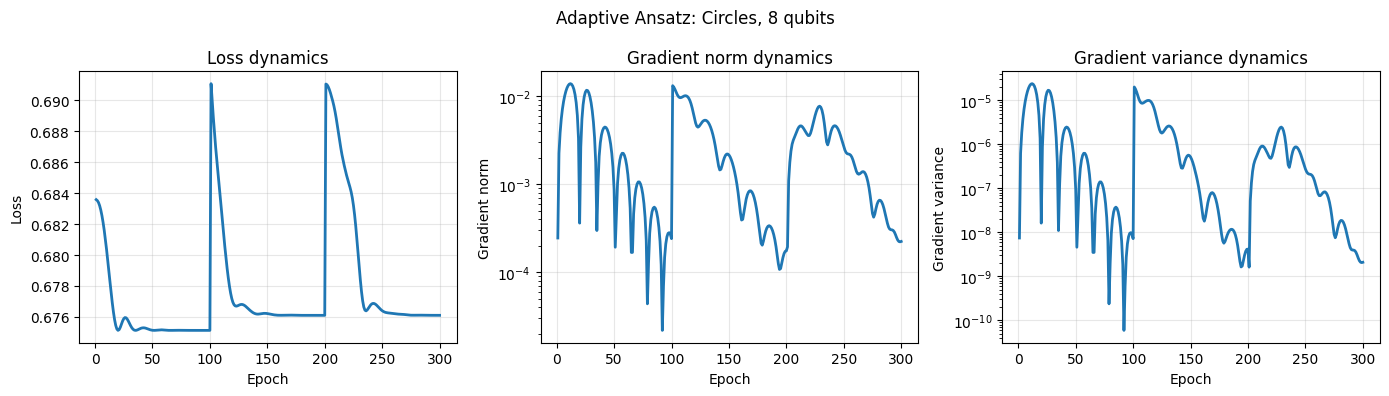


Stage 0 | Dataset: Moons | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.77674 | grad_norm=7.677e-04 | grad_var=2.947e-07
Epoch 050 | loss=0.69239 | grad_norm=1.821e-02 | grad_var=1.657e-04
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: Moons | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.77678 | grad_norm=1.692e-01 | grad_var=1.431e-02
Epoch 050 | loss=0.58513 | grad_norm=1.572e-02 | grad_var=1.235e-04
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: Moons | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.76603 | grad_norm=4.167e-03 | grad_var=3.021e-06
Epoch 050 | loss=0.52078 | grad_norm=3.832e-02 | grad_var=2.048e-04
Detected problem: expressivity_limit
Action: increase_layers_to_2


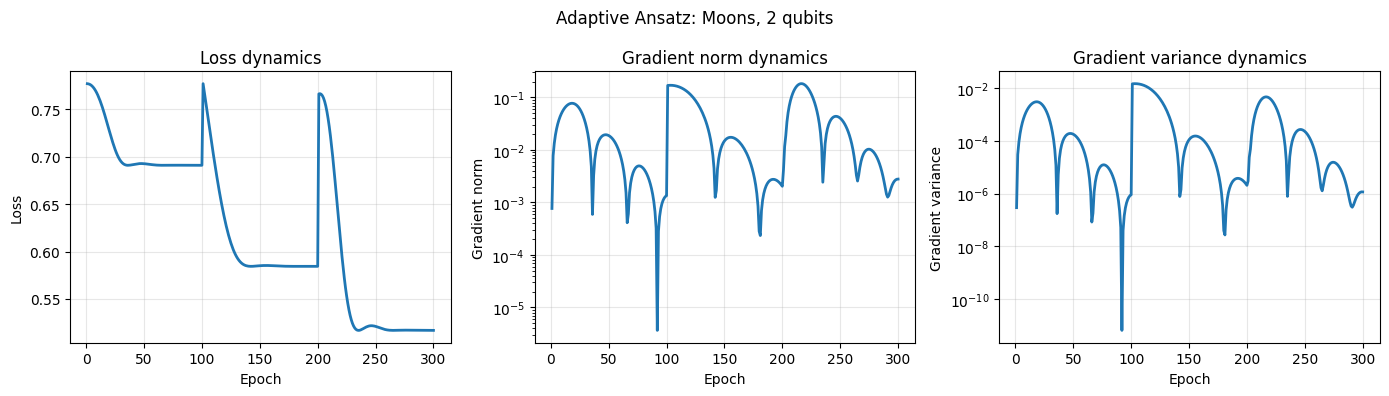


Stage 0 | Dataset: Moons | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.77675 | grad_norm=5.482e-04 | grad_var=7.514e-08
Epoch 050 | loss=0.69239 | grad_norm=1.825e-02 | grad_var=8.330e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: Moons | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.73412 | grad_norm=4.324e-02 | grad_var=2.242e-04
Epoch 050 | loss=0.59438 | grad_norm=2.818e-02 | grad_var=7.241e-05
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: Moons | Qubits: 4 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.73429 | grad_norm=1.683e-03 | grad_var=2.374e-07
Epoch 050 | loss=0.59653 | grad_norm=2.822e-02 | grad_var=6.186e-05
Detected problem: expressivity_limit
Action: increase_layers_to_2


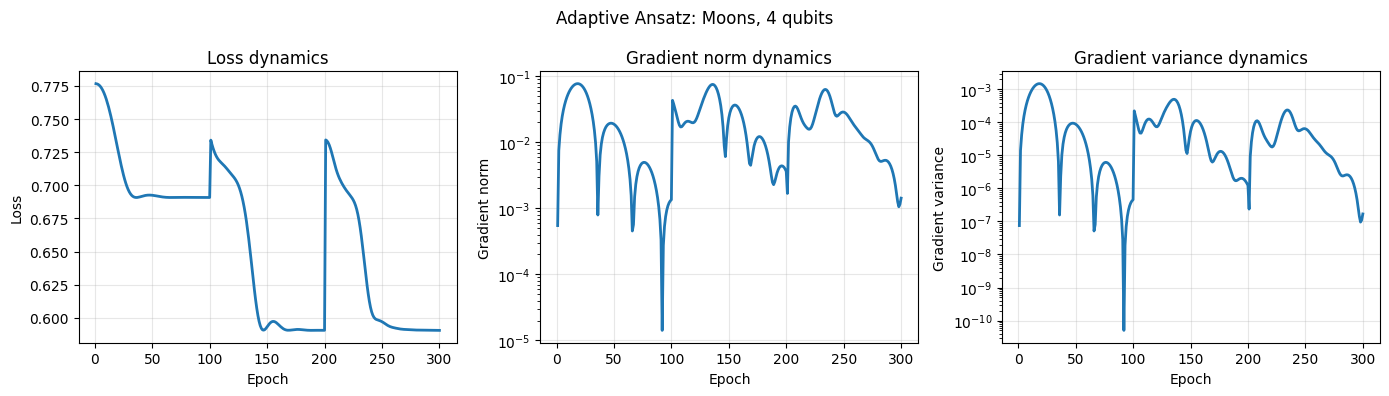


Stage 0 | Dataset: Moons | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.77671 | grad_norm=3.212e-03 | grad_var=1.290e-06
Epoch 050 | loss=0.69230 | grad_norm=1.776e-02 | grad_var=3.943e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: Moons | Qubits: 8 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.69833 | grad_norm=1.917e-02 | grad_var=4.162e-05
Epoch 050 | loss=0.65958 | grad_norm=7.616e-03 | grad_var=7.722e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: Moons | Qubits: 8 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.69830 | grad_norm=3.883e-04 | grad_var=6.519e-09
Epoch 050 | loss=0.67796 | grad_norm=1.137e-02 | grad_var=5.617e-06
Detected problem: expressivity_limit
Action: increase_layers_to_2


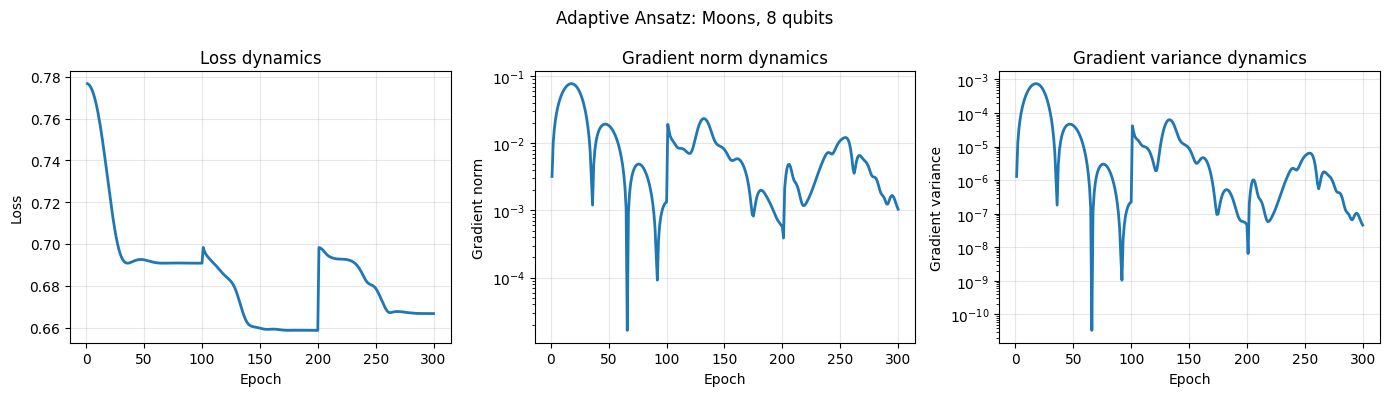

In [46]:
adaptive_results = []
adaptive_histories = {}
adaptive_logs = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("Circles", X_circles_train, X_circles_test, y_circles_train, y_circles_test),
    ("Moons", X_moons_train, X_moons_test, y_moons_train, y_moons_test)
]:
    for q in [2, 4, 8]:
        result, history, log = run_adaptive_ansatz_experiment(
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
            dataset_name=dataset_name,
            n_qubits=q,
            epochs_per_stage=100,
            lr=0.05,
            grad_threshold=1e-4
        )

        adaptive_results.append(result)

        key = f"{dataset_name}_adaptive_{q}"
        adaptive_histories[key] = history
        adaptive_logs[key] = log

        plot_barren_plateau_diagnostics(
            history,
            title=f"Adaptive Ansatz: {dataset_name}, {q} qubits"
        )

In [47]:
adaptive_df = pd.DataFrame(adaptive_results)
adaptive_df

,Dataset,Model,n_qubits,Final_Ansatz,Final_Layers,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,Circles,AdaptiveAnsatzVQC,2,ry_cz,1,0.675133,0.000305,5.799924e-08,0.609333,0.579447,0.871429,0.696058
1,Circles,AdaptiveAnsatzVQC,4,strong,1,0.646309,0.000050,2.173045e-10,0.615333,0.592168,0.805195,0.682444
2,Circles,AdaptiveAnsatzVQC,8,strong,2,0.676106,0.000375,7.065816e-09,0.601333,0.594298,0.703896,0.644471
3,Moons,AdaptiveAnsatzVQC,2,strong,2,0.516951,0.003255,1.998676e-06,0.825333,0.835092,0.822078,0.828534
4,Moons,AdaptiveAnsatzVQC,4,strong,2,0.590498,0.003747,1.516398e-06,0.726667,0.741287,0.718182,0.729551
5,Moons,AdaptiveAnsatzVQC,8,strong,2,0.666707,0.001675,1.241406e-07,0.597333,0.620290,0.555844,0.586301


### Rebuilding Logs

Для исследовательской части важно не только итоговое качество, но и сам процесс принятия решений. Поэтому отдельно выведем таблицу, где видно, какой тип проблемы был обнаружен и какое действие было выполнено.

Эта таблица помогает интерпретировать поведение адаптивной стратегии: модель либо сохраняет текущий Ansatz, либо усложняет его при нехватке выразительности, либо упрощает при признаках Barren Plateau.

In [48]:
adaptive_log_rows = []

for experiment_name, logs in adaptive_logs.items():
    for row in logs:
        current_row = row.copy()
        current_row["Experiment"] = experiment_name
        adaptive_log_rows.append(current_row)

adaptive_log_df = pd.DataFrame(adaptive_log_rows)
adaptive_log_df

,stage,problem_type,action,ansatz,layers,Experiment
0,0,expressivity_limit,switch_to_basic,ry_cz,1,Circles_adaptive_2
1,1,barren_plateau,simplify_to_ry_cz,basic,1,Circles_adaptive_2
2,2,expressivity_limit,switch_to_basic,ry_cz,1,Circles_adaptive_2
3,0,expressivity_limit,switch_to_basic,ry_cz,1,Circles_adaptive_4
4,1,expressivity_limit,switch_to_strong,basic,1,Circles_adaptive_4
5,2,barren_plateau,simplify_to_basic,strong,1,Circles_adaptive_4
6,0,expressivity_limit,switch_to_basic,ry_cz,1,Circles_adaptive_8
7,1,expressivity_limit,switch_to_strong,basic,1,Circles_adaptive_8
8,2,expressivity_limit,increase_layers_to_2,strong,2,Circles_adaptive_8
9,0,expressivity_limit,switch_to_basic,ry_cz,1,Moons_adaptive_2


### Experimental Conclusion

В результате дополнительного эксперимента была проведена диагностика процесса обучения вариационных квантовых классификаторов при увеличении числа кубитов. Основное внимание уделялось не только итоговому качеству классификации, но и динамике оптимизации: функции потерь, норме градиента и дисперсии градиента. Такой анализ позволяет отличать обычное ухудшение качества модели от ситуации, близкой к Barren Plateau.

Практический критерий диагностики был основан на двух величинах:

$$
\Delta C = \bar{C}_{prev} - \bar{C}_{curr}
$$

где:

- $\Delta C$ — изменение функции потерь между двумя соседними окнами эпох;
- $\bar{C}_{prev}$ — среднее значение loss на предыдущем окне эпох;
- $\bar{C}_{curr}$ — среднее значение loss на текущем окне эпох.

Также использовалась средняя норма градиента на последних эпохах:

$$
\bar{G} = \frac{1}{K}\sum_{t=T-K+1}^{T}\|\nabla C_t(\theta)\|_2
$$

где:

- $\bar{G}$ — средняя норма градиента на последних $K$ эпохах;
- $K$ — размер окна усреднения;
- $T$ — общее число эпох обучения;
- $\nabla C_t(\theta)$ — градиент функции стоимости на эпохе $t$;
- $\theta$ — параметры квантовой схемы.

Если $\Delta C$ становится малым, но $\bar{G}$ остаётся ненулевым, это указывает не столько на Barren Plateau, сколько на нехватку выразительности текущего Ansatz. В такой ситуации модель ещё получает обучающий сигнал, но текущая структура схемы недостаточно хорошо аппроксимирует разделяющую поверхность. Если же одновременно $\Delta C$ мало и $\bar{G}$ близко к нулю, это является более сильным практическим признаком Barren Plateau.

В базовой диагностике `VQC_diagnostic` видно, что при увеличении числа кубитов качество модели ухудшается. Для датасета `Circles` значение F1-score снизилось с `0.6916` при 2 кубитах до `0.6398` при 8 кубитах. Для датасета `Moons` деградация выражена сильнее: F1-score снизился с `0.8210` при 2 кубитах до `0.7088` при 8 кубитах. Это показывает, что увеличение числа кубитов само по себе не приводит к улучшению качества модели. Напротив, при фиксированной архитектуре квантовой схемы рост числа кубитов может ухудшать обучаемость.

Дополнительно важно, что нормы градиентов во всех экспериментах с базовой `VQC` остаются малыми. Например, для `Moons` средняя норма градиента за последние эпохи уменьшилась с `4.88e-04` при 2 кубитах до значений порядка `1e-04` при 4 и 8 кубитах. Для `Circles` зависимость получилась не строго монотонной, однако все значения также находятся в малом диапазоне порядка `1e-04`. Это означает, что квантовая модель обучается в условиях слабого градиентного сигнала.

Сравнение разных Ansatz показало, что архитектура квантовой схемы существенно влияет на устойчивость обучения. На датасете `Circles` ручной Ansatz `RY + CZ` оказался наиболее стабильным: F1-score сохранился примерно на уровне `0.695` для 2, 4 и 8 кубитов. Это говорит о том, что простая схема с ограниченной запутанностью может быть устойчивее при масштабировании числа кубитов. В то же время `StronglyEntanglingLayers` при 8 кубитах показал заметное ухудшение: F1-score снизился до `0.5407`, что является самым слабым результатом среди рассмотренных схем на `Circles`.

На датасете `Moons` поведение оказалось другим. Здесь `StronglyEntanglingLayers` был лучшим при 2 кубитах: F1-score составил `0.8210`. Однако при увеличении числа кубитов качество постепенно снижалось: до `0.7916` при 4 кубитах и до `0.7414` при 8 кубитах. Это подтверждает, что более выразительная схема может быть полезной на малом числе кубитов, но при масштабировании начинает терять устойчивость. При этом `BasicEntanglerLayers` показал более стабильную динамику на `Moons`: F1-score вырос с `0.6937` при 2 кубитах до `0.7654` при 8 кубитах. Это указывает на то, что умеренно выразительный Ansatz может быть более подходящим компромиссом между обучаемостью и выразительной способностью.

Таким образом, результаты подтверждают важный вывод: проблема возникает не только из-за количества кубитов, но и из-за сочетания числа кубитов, глубины схемы, типа Ansatz и способа кодирования данных. Слишком простая схема может не иметь достаточной выразительности, а слишком сложная схема может быстрее приводить к исчезающим градиентам.

Это можно выразить через два разных режима плохого обучения:

$$
\Delta C < \varepsilon_C,\quad \bar{G} \geq \varepsilon_G
$$

где:

- $\varepsilon_C$ — минимальное значимое улучшение loss;
- $\varepsilon_G$ — пороговое значение нормы градиента;
- $\Delta C$ — улучшение функции потерь;
- $\bar{G}$ — средняя норма градиента.

Этот случай соответствует ограничению выразительности. Loss почти не улучшается, но градиенты ещё сохраняются. Значит, схему можно попробовать усложнить.

Другой случай:

$$
\Delta C < \varepsilon_C,\quad \bar{G} < \varepsilon_G
$$

где обозначения такие же, как выше. Этот случай ближе к Barren Plateau: loss почти не меняется, а градиентный сигнал становится слишком слабым. В такой ситуации дальнейшее усложнение схемы может быть вредным, потому что оно увеличивает размерность параметрического пространства и может ещё сильнее сгладить ландшафт функции потерь.

Адаптивная стратегия пересборки Ansatz показала, что предложенный механизм действительно позволяет различать эти два режима. В логах адаптивной пересборки большинство случаев были определены как `expressivity_limit`. Это означает, что во многих запусках модель не столько попадала в чистое Barren Plateau, сколько сталкивалась с нехваткой выразительности текущей простой схемы. Поэтому стратегия последовательно переходила от `ry_cz` к `basic`, затем к `strong`, а в некоторых случаях увеличивала число слоёв.

Отдельно признаки `barren_plateau` были зафиксированы для `Circles` при 2 и 4 кубитах. Это важное наблюдение: на датасете `Circles` сама задача имеет ограничение по разделимости. Ранее было показано, что приближённая верхняя граница качества для `Circles` составляет около `0.6924`, а radial overlap равен `0.6152`. Поэтому даже при изменении квантовой схемы модель не может сильно превысить естественное ограничение, связанное со структурой данных. В такой ситуации плато функции потерь может быть связано не только с квантовым barren plateau, но и с ограниченной разделимостью самого датасета.

Для `Moons` ситуация отличается. Приближённая верхняя граница качества для этого датасета значительно выше и составляет около `0.9920`, а overlap существенно меньше. Поэтому ухудшение качества при росте числа кубитов здесь скорее связано не с неразделимостью данных, а с особенностями оптимизации квантовой схемы. Это особенно заметно по результатам `VQC_diagnostic`: F1-score падает с `0.8210` до `0.7088` при переходе от 2 к 8 кубитам.

Адаптивная модель показала лучший результат на `Moons` при 2 кубитах: F1-score составил `0.8285`, что немного выше результата фиксированного `StronglyEntanglingLayers`. Однако при 4 и 8 кубитах адаптивная стратегия не дала улучшения качества: F1-score снизился до `0.7296` и `0.5863` соответственно. Это показывает, что текущий вариант адаптивной пересборки не является универсальным способом повышения accuracy. Его основная ценность заключается не в гарантированном улучшении метрик, а в диагностике состояния обучения и управлении сложностью схемы.

На датасете `Circles` адаптивная стратегия дала F1-score `0.6961` при 2 кубитах, `0.6824` при 4 кубитах и `0.6445` при 8 кубитах. Эти значения близки к лучшим фиксированным схемам и соответствуют ограниченной сложности самого датасета. При этом адаптивная стратегия сохраняет интерпретируемость процесса: по логам видно, когда модель пытается усложнить Ansatz, а когда фиксирует признаки Barren Plateau и возвращается к более простой схеме.

Итоговый вывод состоит в том, что увеличение числа кубитов не должно рассматриваться как автоматический способ улучшения квантовой модели. Напротив, при фиксированном Ansatz рост числа кубитов может приводить к ухудшению качества и ослаблению градиентного сигнала. Для устойчивого обучения необходимо контролировать не только итоговые метрики, но и динамику градиентов.

Проведённый эксперимент показывает, что для борьбы с Barren Plateaus перспективна не одна конкретная схема, а стратегия управления сложностью Ansatz. Простые схемы вроде `RY + CZ` могут быть полезны как стартовая точка, потому что они лучше сохраняют обучаемость. Более сложные схемы вроде `StronglyEntanglingLayers` могут давать высокое качество на малом числе кубитов, но при масштабировании становятся менее устойчивыми. `BasicEntanglerLayers` в ряде случаев выступает как промежуточный вариант между выразительностью и стабильностью.

Таким образом, предложенная динамическая пересборка Ansatz является исследовательским механизмом для анализа и контроля обучения вариационных квантовых моделей. Она позволяет отделить нехватку выразительности от Barren Plateau, отслеживать деградацию градиентов и принимать решение о том, следует ли усложнять или упрощать квантовую схему. В дальнейшей работе эту стратегию можно улучшить за счёт более точного критерия пересборки, сохранения весов между стадиями, использования локальных функций стоимости и подбора порогов $\varepsilon_C$ и $\varepsilon_G$ для каждого датасета отдельно